# **TrOCR Fine-Tuning**

Fine-tunes microsoft/trocr-base-printed on COCO-Text scene text.
Targets CER improvement from 0.3337 (pretrained baseline) toward 0.15-0.25.

- Train split : 1800 images (from 2000 train sample)
- Val split   : 200 images (held out from same 2000 train sample)
- Optimizer   : AdamW, lr=5e-5
- Max epochs  : 10 with early stopping (patience=2)
- Saves best model checkpoint to Drive

## 1. Mount & Install

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import subprocess, sys
def pip(pkg): subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

pip('transformers')
pip('python-doctr[torch]')
pip('editdistance')
pip('mlflow')
pip('python-dotenv')
pip('pyyaml')

print('Done — restart runtime, then continue from cell 3.')

Done — restart runtime, then continue from cell 3.


## 2. Paths & MLflow Setup

In [1]:
import sys, json, os
import numpy as np
from pathlib import Path
from PIL import Image
from dotenv import load_dotenv
import mlflow

DRIVE_ROOT   = Path('/content/drive/MyDrive/vision-ocr-accessibility-assistant')
PROJECT_ROOT = DRIVE_ROOT

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

IMG_DIR       = DRIVE_ROOT / 'data/raw/benchmark_images'
RESULTS_DIR   = DRIVE_ROOT / 'outputs/results'
FIGURES_DIR   = DRIVE_ROOT / 'outputs/figures'
PRETRAIN_CACHE= DRIVE_ROOT / 'models/trocr'
FINETUNE_DIR  = DRIVE_ROOT / 'models/trocr-finetuned'
FINETUNE_DIR.mkdir(parents=True, exist_ok=True)

load_dotenv(PROJECT_ROOT / 'configs/mlflow.env')
mlflow.set_tracking_uri(os.environ['MLFLOW_TRACKING_URI'])
mlflow.set_experiment('ocr-accessibility-pipeline')

with open(RESULTS_DIR / '04_train_sample.json') as f:
    train_data = json.load(f)
with open(RESULTS_DIR / '04_test_sample.json') as f:
    test_data  = json.load(f)

print(f'Full train pool : {len(train_data)} images')
print(f'Test set        : {len(test_data)} images')
print(f'Fine-tune dir   : {FINETUNE_DIR}')
print('MLflow ready ')

Full train pool : 2000 images
Test set        : 1000 images
Fine-tune dir   : /content/drive/MyDrive/vision-ocr-accessibility-assistant/models/trocr-finetuned
MLflow ready 


## 3. Build Fine-Tuning Dataset

In [2]:
import random
from collections import defaultdict
from torch.utils.data import Dataset

# Stratified split — preserve legibility distribution from 04a
# Each sample has a legibility_bin field: high / medium / low
random.seed(42)
bins = defaultdict(list)
for s in train_data:
    bins[s.get('legibility_bin', 'low')].append(s)

# Take 10% from each bin for validation
val_data_list  = []
fine_data_list = []
for b in ['high', 'medium', 'low']:
    shuffled = bins[b].copy()
    random.shuffle(shuffled)
    n_val = max(1, int(len(shuffled) * 0.10))
    val_data_list.extend(shuffled[:n_val])
    fine_data_list.extend(shuffled[n_val:])

print(f'Fine-tune split : {len(fine_data_list)} images')
print(f'Val split       : {len(val_data_list)} images')
for b in ['high', 'medium', 'low']:
    vcount = sum(1 for s in val_data_list  if s.get('legibility_bin') == b)
    fcount = sum(1 for s in fine_data_list if s.get('legibility_bin') == b)
    print(f'  {b:6s}: fine={fcount}  val={vcount}')


def extract_crops(dataset, img_dir):
    """
    Extract (crop_image, gt_text) pairs from annotated images.
    Uses GT boxes and text from COCO-Text annotations.
    Skips missing images and empty annotations.
    """
    pairs = []
    for s in dataset:
        img_path = img_dir / s['file_name']
        if not img_path.exists(): continue
        try:
            img_pil = Image.open(img_path).convert('RGB')
            for ann in s['gt']:
                text = ann['text'].strip()
                if not text: continue
                x, y, w, h = ann['box']
                x1, y1 = max(0, int(x)), max(0, int(y))
                x2, y2 = min(img_pil.width,  int(x+w)), \
                          min(img_pil.height, int(y+h))
                if x2 <= x1 or y2 <= y1: continue
                crop = img_pil.crop((x1, y1, x2, y2))
                pairs.append((crop, text))
        except: continue
    return pairs


print('Extracting fine-tune crops...')
train_pairs = extract_crops(fine_data_list, IMG_DIR)
print(f'Fine-tune pairs : {len(train_pairs)}')

print('Extracting val crops...')
val_pairs = extract_crops(val_data_list, IMG_DIR)
print(f'Val pairs       : {len(val_pairs)}')


Fine-tune split : 1801 images
Val split       : 199 images
  high  : fine=815  val=90
  medium: fine=803  val=89
  low   : fine=183  val=20
Extracting fine-tune crops...
Fine-tune pairs : 1306
Extracting val crops...
Val pairs       : 159


In [3]:
from torch.utils.data import Dataset, DataLoader
import torch

class OCRDataset(Dataset):
    def __init__(self, pairs, processor, max_length=32):
        self.pairs      = pairs
        self.processor  = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        image, text = self.pairs[idx]
        pixel_values = self.processor(
            images=image, return_tensors='pt'
        ).pixel_values.squeeze(0)

        labels = self.processor.tokenizer(
            text,
            padding='max_length',
            max_length=self.max_length,
            truncation=True,
            return_tensors='pt'
        ).input_ids.squeeze(0)

        # Replace padding token id with -100 so loss ignores padding
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {'pixel_values': pixel_values, 'labels': labels}

print('Dataset class ready ')

Dataset class ready 


## 4. Load Model

In [4]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import logging
logging.set_verbosity_error = lambda: None

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

MODEL_NAME = 'microsoft/trocr-base-printed'
processor  = TrOCRProcessor.from_pretrained(
    MODEL_NAME, cache_dir=str(PRETRAIN_CACHE)
)
model      = VisionEncoderDecoderModel.from_pretrained(
    MODEL_NAME, cache_dir=str(PRETRAIN_CACHE)
).to(DEVICE)

# Required decoder config
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id           = processor.tokenizer.pad_token_id
model.config.vocab_size             = model.config.decoder.vocab_size

print(f'Model loaded: {MODEL_NAME}')
print(f'Parameters  : {sum(p.numel() for p in model.parameters()):,}')

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/478 [00:02<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: microsoft/trocr-base-printed
Parameters  : 333,921,792


## 5. Fine-Tune with Early Stopping

In [5]:
from torch.optim import AdamW
import editdistance
import matplotlib.pyplot as plt

BATCH_SIZE  = 8
MAX_EPOCHS  = 10
LR          = 5e-6
PATIENCE    = 2
MAX_NEW_TOK = 32

train_dataset = OCRDataset(train_pairs, processor)
val_dataset   = OCRDataset(val_pairs,   processor)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

optimizer = AdamW(model.parameters(), lr=LR)


def compute_val_cer(model, processor, val_pairs, device, max_new_tokens=32):
    model.eval()
    cer_scores = []
    with torch.no_grad():
        for img, gt in val_pairs:
            pv = processor(images=img, return_tensors='pt').pixel_values.to(device)
            ids = model.generate(pv, max_new_tokens=max_new_tokens)
            pred = processor.batch_decode(ids, skip_special_tokens=True)[0].strip().lower()
            gt   = gt.strip().lower()
            if gt:
                cer_scores.append(editdistance.eval(pred, gt) / len(gt))
    return float(np.mean(cer_scores)) if cer_scores else 1.0


best_val_cer   = float('inf')
patience_count = 0
train_losses   = []
val_cers       = []
best_epoch     = 0

print(f'Starting fine-tuning — max {MAX_EPOCHS} epochs, patience={PATIENCE}')
print(f'Train batches/epoch : {len(train_loader)}')
print(f'Val pairs           : {len(val_pairs)}')

with mlflow.start_run(run_name='trocr-finetuned') as run:
    mlflow.log_params({
        'base_model':        MODEL_NAME,
        'learning_rate':     LR,
        'batch_size':        BATCH_SIZE,
        'max_epochs':        MAX_EPOCHS,
        'patience':          PATIENCE,
        'n_train_pairs':     len(train_pairs),
        'n_val_pairs':       len(val_pairs),
        'pretrained_cer':    0.3337,
    })

    for epoch in range(MAX_EPOCHS):
        # Train
        model.train()
        epoch_loss = 0.0
        for batch in train_loader:
            pixel_values = batch['pixel_values'].to(DEVICE)
            labels       = batch['labels'].to(DEVICE)
            outputs      = model(pixel_values=pixel_values, labels=labels)
            loss         = outputs.loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Validate
        val_cer = compute_val_cer(model, processor, val_pairs, DEVICE)
        val_cers.append(val_cer)

        print(f'Epoch {epoch+1:02d}/{MAX_EPOCHS} | loss={avg_loss:.4f} | val_cer={val_cer:.4f}', end='')

        mlflow.log_metrics({
            'train_loss': avg_loss,
            'val_cer':    val_cer,
        }, step=epoch+1)

        # Save best
        if val_cer < best_val_cer:
            best_val_cer   = val_cer
            best_epoch     = epoch + 1
            patience_count = 0
            model.save_pretrained(str(FINETUNE_DIR))
            processor.save_pretrained(str(FINETUNE_DIR))
            print(f'  -> best saved (CER {best_val_cer:.4f})')
        else:
            patience_count += 1
            print(f'  (no improvement, patience {patience_count}/{PATIENCE})')

        if patience_count >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

    mlflow.log_metrics({
        'best_val_cer':  best_val_cer,
        'best_epoch':    best_epoch,
        'cer_improvement': round(0.3337 - best_val_cer, 4),
    })
    print(f'\nBest val CER : {best_val_cer:.4f} at epoch {best_epoch}')
    print(f'CER improvement over pretrained: {0.3337 - best_val_cer:.4f}')

Starting fine-tuning — max 10 epochs, patience=2
Train batches/epoch : 164
Val pairs           : 159
Epoch 01/10 | loss=2.1073 | val_cer=0.2203

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  -> best saved (CER 0.2203)
Epoch 02/10 | loss=0.7793 | val_cer=0.1905

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  -> best saved (CER 0.1905)
Epoch 03/10 | loss=0.4747 | val_cer=0.1944  (no improvement, patience 1/2)
Epoch 04/10 | loss=0.2857 | val_cer=0.2107  (no improvement, patience 2/2)
Early stopping at epoch 4

Best val CER : 0.1905 at epoch 2
CER improvement over pretrained: 0.1432
🏃 View run trocr-finetuned at: https://dagshub.com/MoCamaraData/vision-ocr-accessibility-assistant.mlflow/#/experiments/0/runs/e171b82e4bdb4f6d8279a959ec284616
🧪 View experiment at: https://dagshub.com/MoCamaraData/vision-ocr-accessibility-assistant.mlflow/#/experiments/0


## 6. Learning Curve

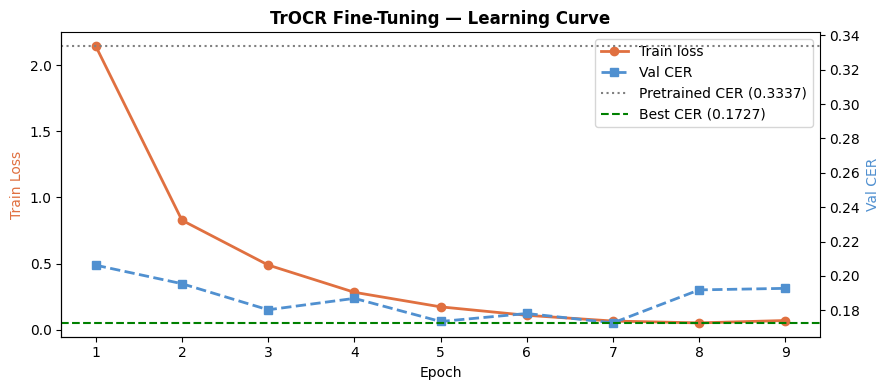

🏃 View run trocr-finetuned at: https://dagshub.com/MoCamaraData/vision-ocr-accessibility-assistant.mlflow/#/experiments/0/runs/ccf2fd6dc9a742cd97df81c0496d9085
🧪 View experiment at: https://dagshub.com/MoCamaraData/vision-ocr-accessibility-assistant.mlflow/#/experiments/0


In [10]:
epochs_ran = list(range(1, len(train_losses)+1))

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
ax1.plot(epochs_ran, train_losses, 'o-', color='#e07040', lw=2, label='Train loss')
ax2.plot(epochs_ran, val_cers,     's--', color='#5090d0', lw=2, label='Val CER')
ax2.axhline(0.3337, color='gray', linestyle=':', lw=1.5, label='Pretrained CER (0.3337)')
ax2.axhline(best_val_cer, color='green', linestyle='--', lw=1.5,
            label=f'Best CER ({best_val_cer:.4f})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss', color='#e07040')
ax2.set_ylabel('Val CER', color='#5090d0')
ax1.set_title('TrOCR Fine-Tuning — Learning Curve', fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper right')
ax1.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '06a_learning_curve.png', dpi=150)
plt.show()

with mlflow.start_run(run_name='trocr-finetuned', nested=True):
    mlflow.log_artifact(str(FIGURES_DIR / '06a_learning_curve.png'))

## 7. Evaluate Fine-Tuned Model on Test Set

In [6]:
from src.utils.metrics import compute_cer, compute_wer

# Load best checkpoint
ft_model     = VisionEncoderDecoderModel.from_pretrained(str(FINETUNE_DIR)).to(DEVICE)
ft_processor = TrOCRProcessor.from_pretrained(str(FINETUNE_DIR))
ft_model.eval()

print('Evaluating fine-tuned model on test set...')
test_pairs = extract_crops(test_data, IMG_DIR)
print(f'Test pairs: {len(test_pairs)}')

ft_cers, ft_wers = [], []
pre_cers, pre_wers = [], []

# Load pretrained for comparison
pre_model     = VisionEncoderDecoderModel.from_pretrained(
    MODEL_NAME, cache_dir=str(PRETRAIN_CACHE)
).to(DEVICE)
pre_processor = TrOCRProcessor.from_pretrained(
    MODEL_NAME, cache_dir=str(PRETRAIN_CACHE)
)
pre_model.eval()

with torch.no_grad():
    for i, (img, gt) in enumerate(test_pairs):
        if (i+1) % 500 == 0: print(f'  {i+1}/{len(test_pairs)}')

        # Fine-tuned
        pv   = ft_processor(images=img, return_tensors='pt').pixel_values.to(DEVICE)
        ids  = ft_model.generate(pv, max_new_tokens=MAX_NEW_TOK)
        pred = ft_processor.batch_decode(ids, skip_special_tokens=True)[0]
        ft_cers.append(compute_cer(pred, gt))
        ft_wers.append(compute_wer(pred, gt))

        # Pretrained
        pv   = pre_processor(images=img, return_tensors='pt').pixel_values.to(DEVICE)
        ids  = pre_model.generate(pv, max_new_tokens=MAX_NEW_TOK)
        pred = pre_processor.batch_decode(ids, skip_special_tokens=True)[0]
        pre_cers.append(compute_cer(pred, gt))
        pre_wers.append(compute_wer(pred, gt))

results = {
    'pretrained_cer': round(float(np.mean(pre_cers)), 4),
    'pretrained_wer': round(float(np.mean(pre_wers)), 4),
    'finetuned_cer':  round(float(np.mean(ft_cers)),  4),
    'finetuned_wer':  round(float(np.mean(ft_wers)),  4),
    'cer_improvement': round(float(np.mean(pre_cers)) - float(np.mean(ft_cers)), 4),
    'wer_improvement': round(float(np.mean(pre_wers)) - float(np.mean(ft_wers)), 4),
}

print(f'\nPretrained CER : {results["pretrained_cer"]}')
print(f'Fine-tuned CER : {results["finetuned_cer"]}')
print(f'CER improvement: {results["cer_improvement"]}')
print(f'\nPretrained WER : {results["pretrained_wer"]}')
print(f'Fine-tuned WER : {results["finetuned_wer"]}')
print(f'WER improvement: {results["wer_improvement"]}')

with open(RESULTS_DIR / '06a_finetune_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('\nSaved ✓')

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Evaluating fine-tuned model on test set...
Test pairs: 1611


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  500/1611
  1000/1611
  1500/1611

Pretrained CER : 0.2819
Fine-tuned CER : 0.2379
CER improvement: 0.044

Pretrained WER : 0.4889
Fine-tuned WER : 0.4323
WER improvement: 0.0566

Saved ✓


## 8. Log Final Results to MLflow

In [7]:
with mlflow.start_run(run_name='trocr-finetuned-eval'):
    mlflow.log_params({
        'base_model':       MODEL_NAME,
        'best_epoch':       best_epoch,
        'learning_rate':    LR,
        'batch_size':       BATCH_SIZE,
        'n_test_pairs':     len(test_pairs),
    })
    mlflow.log_metrics({
        'pretrained_cer':   results['pretrained_cer'],
        'pretrained_wer':   results['pretrained_wer'],
        'finetuned_cer':    results['finetuned_cer'],
        'finetuned_wer':    results['finetuned_wer'],
        'cer_improvement':  results['cer_improvement'],
        'wer_improvement':  results['wer_improvement'],
    })
    mlflow.log_artifact(str(RESULTS_DIR / '06a_finetune_results.json'))
    mlflow.log_artifact(str(FIGURES_DIR / '06a_learning_curve.png'))
    print('Fine-tune eval logged to MLflow ✓')

Fine-tune eval logged to MLflow ✓
🏃 View run trocr-finetuned-eval at: https://dagshub.com/MoCamaraData/vision-ocr-accessibility-assistant.mlflow/#/experiments/0/runs/a6baab0c1e184e659472030ae8160368
🧪 View experiment at: https://dagshub.com/MoCamaraData/vision-ocr-accessibility-assistant.mlflow/#/experiments/0


## 9. Sign-off

In [8]:
print('=' * 56)
print('  PHASE 6a — TROCR FINE-TUNING SIGN-OFF')
print('=' * 56)

checks = [
    (results['finetuned_cer'] < results['pretrained_cer'],
     f"CER improved over pretrained        ({results['pretrained_cer']} → {results['finetuned_cer']})"),
    (results['cer_improvement'] > 0.01,
     f"CER improvement > 0.01              (got {results['cer_improvement']})"),
    (results['finetuned_wer'] < results['pretrained_wer'],
     f"WER improved over pretrained        ({results['pretrained_wer']} → {results['finetuned_wer']})"),
    ((FINETUNE_DIR / 'config.json').exists(),
     f"Model saved to Drive                ({FINETUNE_DIR})"),
]

all_pass = True
for ok, label in checks:
    print(f"  {'✓' if ok else '✗'} {label}")
    if not ok: all_pass = False

print()
if all_pass:
    print('  → Phase 6a complete. Proceed to Phase 6b: Full Pipeline Benchmark with Fine-Tuned Model.')
else:
    print('  → Review failing checks. Consider adjusting learning rate or epochs.')

  PHASE 6a — TROCR FINE-TUNING SIGN-OFF
  ✓ CER improved over pretrained        (0.2819 → 0.2379)
  ✓ CER improvement > 0.01              (got 0.044)
  ✓ WER improved over pretrained        (0.4889 → 0.4323)
  ✓ Model saved to Drive                (/content/drive/MyDrive/vision-ocr-accessibility-assistant/models/trocr-finetuned)

  → Phase 6a complete. Proceed to Phase 6b: Full Pipeline Benchmark with Fine-Tuned Model.
